# 📘 Taller Evaluativo (20%) - Análisis de Portafolio
### Curso: Ingeniería Financiera / Programación  
### Herramienta: Google Colab  
---
### 🎯 Objetivo
Este taller busca que comprendas qué es un análisis de portafolio, cómo se calculan y analizan sus métricas (rentabilidad, riesgo y correlación), y cómo se interpreta el resultado para tomar decisiones de inversión.

👉 **Importante:** No basta con ejecutar el código. Debes **completar los espacios en blanco**, responder las **preguntas de investigación** y redactar un **análisis final**.

## 1. Importación de librerías
Primero, importa las librerías necesarias para trabajar con datos financieros.

In [ ]:
pip install yfinance

In [14]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


## 2. Descarga de datos
Usa `yfinance` para descargar los precios de **Google (GOOG)**, **Amazon (AMZN)** y **Microsoft (MSFT)** durante los últimos 3 años. Utiliza la columna `Adj Close`.

🔎 **Pregunta:** ¿Por qué es más adecuado usar `Adj Close` que `Close` para un análisis financiero?

R/: El valor Adj Close (cierre ajustado) refleja el precio real de la acción ajustado por dividendos, splits y otros eventos corporativos.
En cambio, Close solo muestra el precio de cierre del día sin ajustes.

Por eso, para análisis históricos y cálculos de rentabilidad es mejor usar Adj Close, porque representa de manera más precisa la evolución del valor real para un inversionista.

En pandas, un KeyError ocurre cuando intentas acceder a una columna que no existe en el DataFrame.
Pero el DataFrame que devuelve yf.download ya viene ajustado porque desde hace poco yfinance cambió su comportamiento:

Antes: devolvía "Open", "High", "Low", "Close", "Adj Close", "Volume".

Ahora: auto_adjust=True por defecto, entonces ya no incluye "Adj Close", solo entrega "Open", "High", "Low", "Close", "Volume", y ese "Close" ya es el ajustado.

Por eso "Adj Close" no existe → aparece el KeyError.

In [15]:
tickers = ['GOOG','AMZN','MSFT']
start = '2022-09-17'
end   = '2025-09-17'

# Forzar que devuelva la columna 'Adj Close'
datos = yf.download(tickers, start=start, end=end, auto_adjust=False)['Adj Close']
datos.head(5)

[*********************100%***********************]  3 of 3 completed


Ticker,AMZN,GOOG,MSFT
Date,,,
2022-09-19,124.660004,103.144142,238.584900
2022-09-20,122.190002,101.137886,236.565125
2022-09-21,118.540001,99.330261,233.150055
2022-09-22,117.309998,99.886452,235.130798
2022-09-23,113.779999,98.495972,232.145065


In [16]:
datos.tail(5) # Veo los últimos 5 datos

Ticker,AMZN,GOOG,MSFT
Date,,,
2025-09-10,230.330002,239.559998,500.369995
2025-09-11,229.949997,240.779999,501.010010
2025-09-12,228.149994,241.380005,509.899994
2025-09-15,231.429993,251.759995,515.359985
2025-09-16,234.050003,251.419998,509.040009


##3. Visualización de precios
Grafica en una misma figura la evolución de los precios de cierre ajustados de las tres acciones.

🔎 Pregunta: ¿Cuál de las tres acciones muestra mayor crecimiento en estos 3 años?

In [17]:
import matplotlib.pyplot as plt


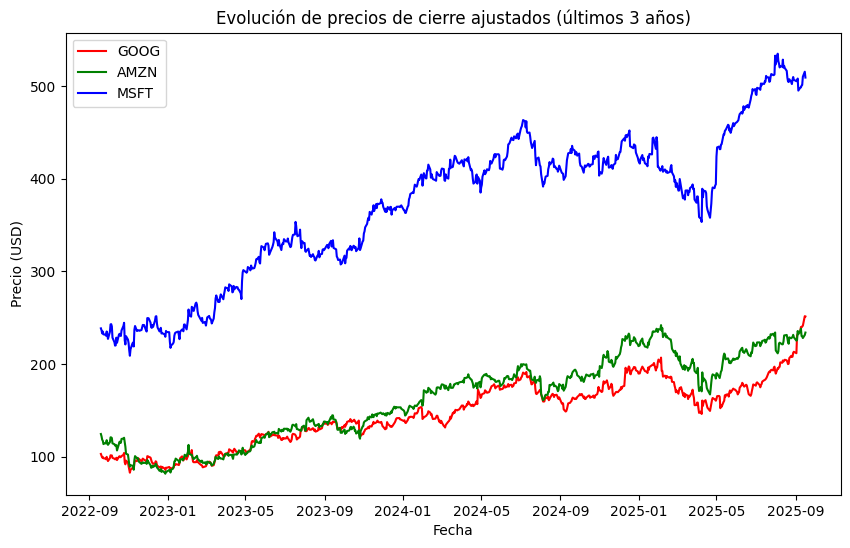

In [18]:
plt.figure(figsize=(10,6))

plt.plot(datos["GOOG"], label="GOOG", color="red")
plt.plot(datos["AMZN"], label="AMZN", color="green")
plt.plot(datos["MSFT"], label="MSFT", color="blue")

plt.title("Evolución de precios de cierre ajustados (últimos 3 años)")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.legend()
plt.show()


#¿Cuál de las tres acciones muestra mayor crecimiento en estos 3 años?

In [19]:
# Precios iniciales y finales
precios_iniciales = datos.iloc[0]
precios_finales = datos.iloc[-1]

# Calcular diferencias
diferencias = precios_finales - precios_iniciales

# Mostrar resultados
print("📊 Comparación de precios en 3 años:\n")
for ticker in datos.columns:
    print(f"{ticker}:")
    print(f"   Precio inicial: {precios_iniciales[ticker]:.2f} USD")
    print(f"   Precio final:   {precios_finales[ticker]:.2f} USD")
    print(f"   Diferencia:     {diferencias[ticker]:.2f} USD\n")

# Identificar la acción con mayor crecimiento
ganador = diferencias.idxmax()
print(f"🏆 La acción con mayor crecimiento absoluto en precio es: {ganador}")


📊 Comparación de precios en 3 años:

AMZN:
   Precio inicial: 124.66 USD
   Precio final:   234.05 USD
   Diferencia:     109.39 USD

GOOG:
   Precio inicial: 103.14 USD
   Precio final:   251.42 USD
   Diferencia:     148.28 USD

MSFT:
   Precio inicial: 238.58 USD
   Precio final:   509.04 USD
   Diferencia:     270.46 USD

🏆 La acción con mayor crecimiento absoluto en precio es: MSFT


## 4. Rentabilidades
Calcula las rentabilidades logarítmicas diarias y grafícalas.

🔎 Pregunta: ¿Qué diferencias encuentras entre observar precios y observar rentabilidades?

#Formula


$r_t = \ln(\frac{P_t}{P_{t-1}})$

In [20]:
# Calcular rentabilidades logarítmicas diarias
rendimientos = np.log(datos / datos.shift(1))
rendimientos.head()


Ticker,AMZN,GOOG,MSFT
Date,,,
2022-09-19,NaN,NaN,NaN
2022-09-20,-0.020013,-0.019643,-0.008502
2022-09-21,-0.030327,-0.018035,-0.014541
2022-09-22,-0.010430,0.005584,0.008460
2022-09-23,-0.030553,-0.014018,-0.012779


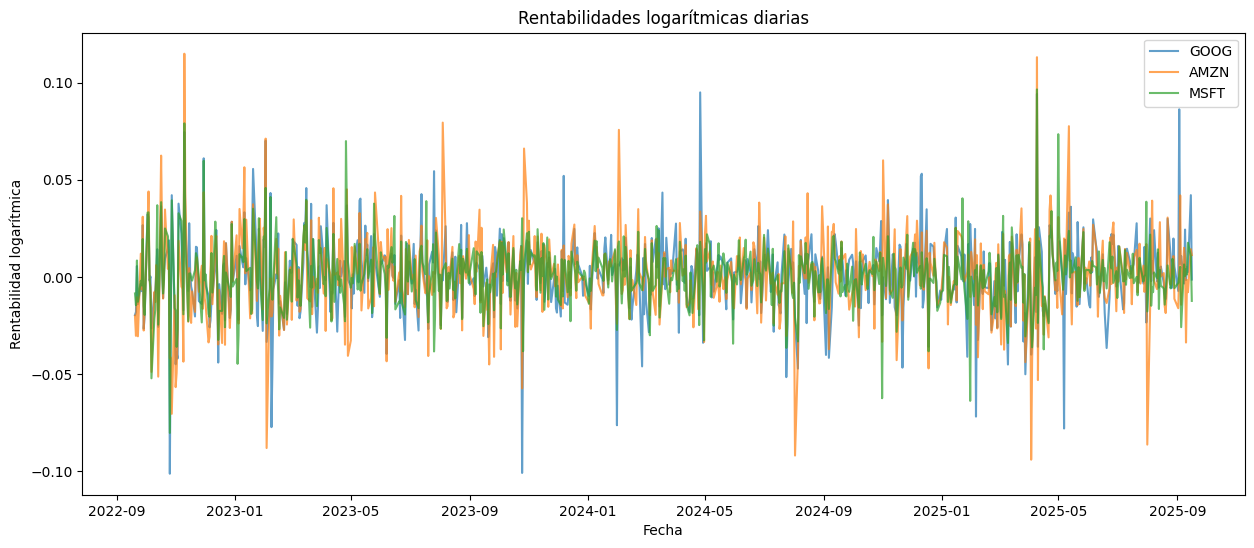

In [21]:
plt.figure(figsize=(15,6))
plt.plot(rendimientos["GOOG"], label="GOOG", alpha=0.7)
plt.plot(rendimientos["AMZN"], label="AMZN", alpha=0.7)
plt.plot(rendimientos["MSFT"], label="MSFT", alpha=0.7)

plt.title("Rentabilidades logarítmicas diarias")
plt.xlabel("Fecha")
plt.ylabel("Rentabilidad logarítmica")
plt.legend()
plt.show()


La fórmula que estamos utilizando (rendimiento logarítmico) nos permite transformar precios en rentabilidades. Mientras que observar precios solo nos indica el valor del activo en un momento dado, las rentabilidades nos muestran cómo cambian esos precios en el tiempo. Esta información es esencial para medir el rendimiento, comparar activos y aplicar modelos financieros o estadísticos. Por eso, en lugar de trabajar con los precios directamente, se prefiere analizar las rentabilidades.

#5. Medidas estadísticas
Calcula la rentabilidad promedio y la volatilidad (desviación estándar) de cada acción.



In [22]:
media = rendimientos.mean()
volatilidad = rendimientos.std()

print("Rentabilidad promedio diaria:")
print(media)

print("\nVolatilidad diaria:")
print(volatilidad)

Rentabilidad promedio diaria:
Ticker
AMZN    0.000840
GOOG    0.001188
MSFT    0.001010
dtype: float64

Volatilidad diaria:
Ticker
AMZN    0.021304
GOOG    0.019858
MSFT    0.015998
dtype: float64


🔎 Pregunta: ¿Cuál acción es más riesgosa? ¿Cuál ofrece mayor retorno?

In [23]:
# Identificar acción con mayor retorno
accion_mayor_retorno = media.idxmax()
mayor_retorno = media.max()

# Identificar acción más riesgosa
accion_mas_riesgosa = volatilidad.idxmax()
mayor_riesgo = volatilidad.max()

print("\n📌 Conclusión:")
print(f"La acción con mayor retorno es {accion_mayor_retorno} con {mayor_retorno:.4f}")
print(f"La acción más riesgosa es {accion_mas_riesgosa} con {mayor_riesgo:.4f}")


📌 Conclusión:
La acción con mayor retorno es GOOG con 0.0012
La acción más riesgosa es AMZN con 0.0213


#6. Correlación entre activos
Calcula y grafica la matriz de correlación entre las acciones.

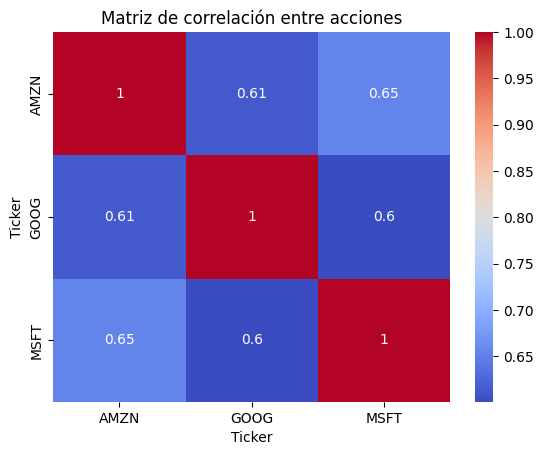

In [25]:
# Calcular matriz de correlación entre las acciones
correlacion = rendimientos.corr()

# Graficar heatmap
sns.heatmap(correlacion, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación entre acciones")
plt.show()

#Interpretación de la correlación entre acciones

1. Correlación cercana a 1 (positiva y fuerte):
Significa que las dos acciones tienden a moverse en la misma dirección.
Cuando una sube, la otra también sube; cuando una baja, la otra baja.
Ejemplo típico: acciones de empresas del mismo sector (como bancos o tecnológicas grandes).

2. Correlación cercana a 0:
Indica que no hay relación lineal clara entre los movimientos de ambas acciones.
Sus precios se comportan de manera prácticamente independiente.

3. Correlación negativa (cercana a -1):
Significa que las acciones tienden a moverse en direcciones opuestas.
Cuando una sube, la otra suele bajar.

#7. Portafolio simulado
Supón un portafolio con la siguiente distribución:


40% Google

30% Amazon

30% Microsoft

Calcula el retorno esperado y la volatilidad del portafolio.

🔎 Preguntas:

¿Cómo interpretas el retorno esperado del portafolio?

¿Qué efecto tuvo la diversificación sobre la volatilidad respecto a invertir en una sola acción?

In [41]:


# Pesos del portafolio (Google 40%, Amazon 30%, Microsoft 30%)
pesos = np.array([0.4, 0.3, 0.3])

# Retorno esperado del portafolio = suma ponderada de los retornos esperados
retorno_portafolio = np.dot(pesos, rendimientos.mean())

# covarianzas de las rentabilidades
covarianza = rendimientos.cov()

# Volatilidad del portafolio (desviación estándar)
vol_portafolio = np.sqrt(np.dot(pesos.T, np.dot(covarianza, pesos)))

print("Retorno esperado del portafolio (diario):", retorno_portafolio)
print("Volatilidad del portafolio (diaria):", vol_portafolio)

Retorno esperado del portafolio (diario): 0.0009954900318321835
Volatilidad del portafolio (diaria): 0.01677466385075116
